In [97]:
%load_ext autoreload
%autoreload 3

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from explainit.priorities.nonlinear import exponential
from explainit.explainers.minlp_search import MINLSearchExplainer
from explainit.priorities.nonlinear import basic_linear_step
from explainit.logging_config import logger

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading California Housing dataset...
Dataset shape: (20640, 9)

First few rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset description:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.46

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3887 - mean_absolute_error: 0.8100 - val_loss: 0.5644 - val_mean_absolute_error: 0.5168
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - loss: 0.6647 - mean_absolute_error: 0.5762 - val_loss: 0.4902 - val_mean_absolute_error: 0.4843
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 0.5397 - mean_absolute_error: 0.5291 - val_loss: 0.4370 - val_mean_absolute_error: 0.4607
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 0.4984 - mean_absolute_error: 0.5066 - val_loss: 0.4209 - val_mean_absolute_error: 0.4526
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 0.4699 - mean_absolute_error: 0.4921 - val_loss: 0.4108 - val_mean_absolute_error: 0.4486
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - loss: 0.4513 - mean_absolute_error: 0.4821 - val_loss: 0.4478 - val_mean_absolute_error: 0.4598
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - loss

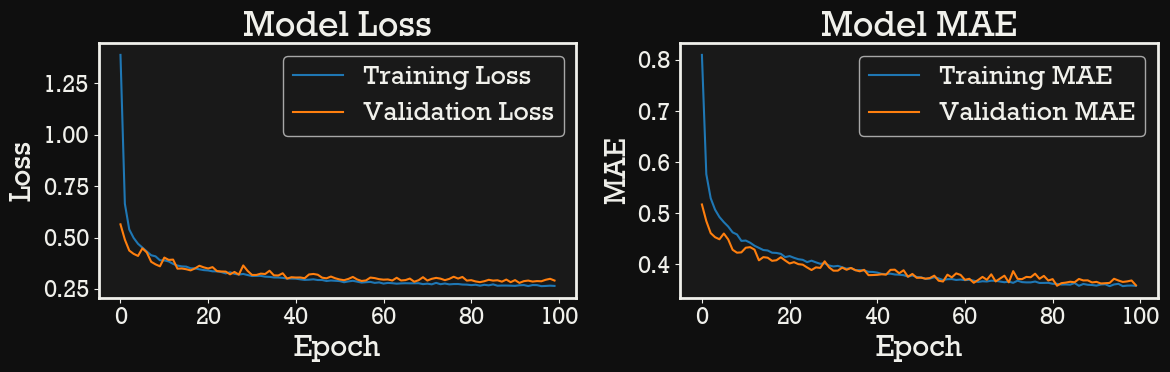

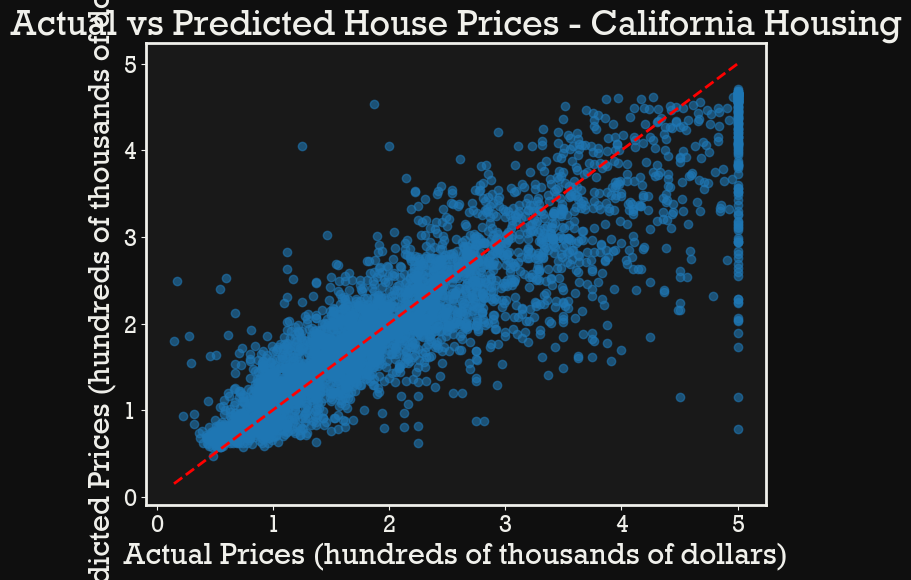


Example prediction for a new house:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted price: $0.64 (hundreds of thousands)
Actual price: $0.48 (hundreds of thousands)
Difference: $0.16 (hundreds of thousands)

Feature names and their indices:
0: MedInc
1: HouseAge
2: AveRooms
3: AveBedrms
4: Population
5: AveOccup
6: Latitude
7: Longitude

Sample house features and prediction:
Features:
  MedInc: 1.6812
  HouseAge: 25.0000
  AveRooms: 4.1922
  AveBedrms: 1.0223
  Population: 1392.0000
  AveOccup: 3.8774
  Latitude: 36.0600
  Longitude: -119.0100
Predicted price: $0.64 hundred thousands
Actual price: $0.48 hundred thousands
MSE: 0.2767
RMSE: 0.5260
MAE: 0.3474
R²: 0.7889
MAPE: 19.0850
Efficiency vs Baseline: 0.7889


In [98]:


# Load the California Housing dataset
print("Loading California Housing dataset...")
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Create DataFrame for better understanding
feature_names = housing.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['PRICE'] = y

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset description:")
print(df.describe())
print("\nFeature descriptions:")
print("MedInc: Median income in block group")
print("HouseAge: Median house age in block group")
print("AveRooms: Average number of rooms per household")
print("AveBedrms: Average number of bedrooms per household")
print("Population: Block group population")
print("AveOccup: Average number of household members")
print("Latitude: Block group latitude")
print("Longitude: Block group longitude")

# Prepare the data
print("\nPreparing data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

# Build the neural network model
print("\nBuilding the model...")
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer for regression (no activation)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

print("Model summary:")
model.summary()

# Train the model
print("\nTraining the model...")
history = model.fit(
    X_train_scaled, y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
print("\nEvaluating the model...")
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Make predictions
print("\nMaking predictions...")
predictions = model.predict(X_test_scaled)

# Calculate additional metrics
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Plot predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices (hundreds of thousands of dollars)')
plt.ylabel('Predicted Prices (hundreds of thousands of dollars)')
plt.title('Actual vs Predicted House Prices - California Housing')
plt.show()

# Example of using the model for new predictions
print("\nExample prediction for a new house:")
# Take the first test sample as an example
sample_house = X_test_scaled[0:1]
predicted_price = model.predict(sample_house)
actual_price = y_test[0]

print(f"Predicted price: ${predicted_price[0][0]:.2f} (hundreds of thousands)")
print(f"Actual price: ${actual_price:.2f} (hundreds of thousands)")
print(f"Difference: ${abs(predicted_price[0][0] - actual_price):.2f} (hundreds of thousands)")

# Feature importance visualization
print("\nFeature names and their indices:")
for i, feature in enumerate(feature_names):
    print(f"{i}: {feature}")

# Show sample predictions with feature values
print("\nSample house features and prediction:")
sample_idx = 0
print("Features:")
for i, (feature, value) in enumerate(zip(feature_names, X_test[sample_idx])):
    print(f"  {feature}: {value:.4f}")
print(f"Predicted price: ${predictions[sample_idx][0]:.2f} hundred thousands")
print(f"Actual price: ${y_test[sample_idx]:.2f} hundred thousands")


# Calculate various efficiency metrics
def calculate_regression_efficiency(y_true, y_pred):
    """Calculate comprehensive efficiency metrics for regression"""
    
    # Basic metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Additional metrics
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Mean Absolute Percentage Error
    
    # Efficiency relative to baseline (mean prediction)
    baseline_mse = mean_squared_error(y_true, [np.mean(y_true)] * len(y_true))
    efficiency_ratio = 1 - (mse / baseline_mse)  # How much better than baseline
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape,
        'Efficiency vs Baseline': efficiency_ratio
    }

# Use with your model
metrics = calculate_regression_efficiency(y_test, predictions.flatten())
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

In [99]:
# Transform the entire feature array with the already-fitted scaler and join with target y
X_scaled_full = scaler.transform(X)  # scaler was fitted on X_train earlier
df_scaled = pd.DataFrame(X_scaled_full, columns=feature_names, index=df.index)
df_scaled['PREDICTED_PRICE'] = model.predict(X_scaled_full)
df_scaled['PRICE'] = y
print("df_scaled shape:", df_scaled.shape)
df_scaled.head()


645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step
df_scaled shape: (20640, 10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PREDICTED_PRICE,PRICE
0,2.333978,0.983304,0.648804,-0.168225,-0.971356,-0.046760,1.046920,-1.320163,3.988994,4.526
1,2.321480,-0.603731,0.336322,-0.288098,0.857105,-0.085255,1.037560,-1.315177,3.983037,3.585
2,1.773228,1.856173,1.195031,-0.053643,-0.818325,-0.025453,1.032879,-1.325149,3.901034,3.521
3,0.925487,1.856173,0.160062,-0.054537,-0.763796,-0.047417,1.032879,-1.330135,2.913950,3.413
4,-0.018146,1.856173,0.354634,-0.036019,-0.757640,-0.079069,1.032879,-1.330135,2.558744,3.422


## 1. Select sample for analysis

In [100]:
sample = [
    0.66349212, # MedInc
    -1.7940068, # HouseAge
    0.29822898, # AveRooms
    -0.13901824, # AveBedrms
    2.05145292, # Population
    -0.04826328, # AveOccup
    1.33242066, # Latitude
    -0.97612513 # Longitude
    ] 
    # 1.89954197, # predicted_price
    # 1.745 # price


## 2. Select model and requested target
In this scenario, the requested target is probability of classification as class '1'. We want to get probability equal to $60\%$. Note, that we cannot use output of the model (model.predict), which output only $0$ or $1$. We need to use model.predict_proba available in LogisticRegression of SciKit-learn. In this case the output are two values: (probability of class '0', probability of class '1'). We are interested only in the latter, so we select $0.60$ as out requested target, meaning "probability of class '1'".

In [101]:
# Ensure the sample is a 2D numpy array with correct dtype and shape before predicting
import numpy as np

def model_pred(x):
	arr = np.asarray(x, dtype=np.float32)
	# single sample as 1D -> reshape to (1, n_features)
	if arr.ndim == 1:
		arr = arr.reshape(1, -1)
	# if arr is higher than 2D, try to reshape to 2D (batch, features)
	elif arr.ndim > 2:
		arr = arr.reshape(arr.shape[0], -1)
	preds = model.predict(arr)
	preds = np.asarray(preds, dtype=np.float32)
	# squeeze to 1D; if scalar, expand to length-1 array so single sample -> array([val])
	preds = np.squeeze(preds)
	if np.ndim(preds) == 0:
		preds = np.expand_dims(preds, 0)
	return preds

target = 3.0

## 3. Indicate barriers and priorities. 
By "barriers" we mean min/max values. By "priorities" we mean weight functions that indicate which values of features are preferable to us and which are not.

### Detailed instructions
The priorities need to be written in dictionary of such format:
```python
{
    'numerical':{
        index x: <priority value>,
        index y: <priority value>,
        ...
    }

    'categorical':{
        (index a1, index b1, ..., index n1) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        },
        (index a2, index b2, ..., index n2) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        }
        ...
    }
}
```

- Numerical (continuous) features:
  - unactionable : use int 0 instead of ```<priority value>```, this means that the value from the sample will be used and will not participate in selection based on priority
  - actionable: use ```{'function':<f(x)>,'min': <min value>, 'max': <max value>}```
    - replace ```<f(x)>``` with given function $f : [0, 1]$ 
    - replace ```<min value>``` and ```<max value>``` with respective values (floats or integers)
- Categorical features:
  - for given indices (index a1, index b1, ..., index n1) create dictionary mapping all possible categories to $0$ (don't use) or $1$ (can be used). The algorithm will then be able to use allowed categories and omit forbidden. You can also use other values than $1$ for permitted categories form range $(0, 1]$ to indicate priority. In this case, larger value makes the priority higher.



In [102]:
df_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PREDICTED_PRICE,PRICE
0,2.333978,0.983304,0.648804,-0.168225,-0.971356,-0.046760,1.046920,-1.320163,3.988994,4.526
1,2.321480,-0.603731,0.336322,-0.288098,0.857105,-0.085255,1.037560,-1.315177,3.983037,3.585
2,1.773228,1.856173,1.195031,-0.053643,-0.818325,-0.025453,1.032879,-1.325149,3.901034,3.521
3,0.925487,1.856173,0.160062,-0.054537,-0.763796,-0.047417,1.032879,-1.330135,2.913950,3.413
4,-0.018146,1.856173,0.354634,-0.036019,-0.757640,-0.079069,1.032879,-1.330135,2.558744,3.422
...,...,...,...,...,...,...,...,...,...,...
20635,-1.218575,-0.286324,-0.163272,0.084599,-0.511382,-0.046324,1.795774,-0.751753,0.677713,0.781
20636,-0.695268,-0.841786,0.284338,0.505780,-0.941453,0.002232,1.800454,-0.811585,0.784372,0.771
20637,-1.145212,-0.921138,-0.096214,0.054034,-0.368905,-0.066618,1.772372,-0.816571,0.797705,0.923
20638,-1.057408,-0.841786,-0.044285,0.173672,-0.602849,-0.084101,1.772372,-0.866432,0.906729,0.847


In [8]:
df_scaled.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PREDICTED_PRICE,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-0.005295,0.002476,-0.002612,-0.000022,-0.000859,-0.002272,-0.005283,0.006275,2.022559,2.068558
std,0.997682,0.998686,1.036389,1.093973,0.995990,0.897020,0.999697,0.998972,0.899348,1.153956
min,-1.775438,-2.190766,-1.922287,-1.762117,-1.251913,-0.207685,-1.452377,-2.377207,0.648679,0.149990
25%,-0.691802,-0.841786,-0.416587,-0.209154,-0.562393,-0.057626,-0.801811,-1.105763,1.368829,1.196000
50%,-0.181676,0.031083,-0.086334,-0.110582,-0.229066,-0.024083,-0.647360,0.544622,1.841795,1.797000
75%,0.452935,0.665897,0.258512,0.006559,0.262569,0.016004,0.967355,0.783953,2.473543,2.647250
max,5.839268,1.856173,57.166552,76.107741,30.127428,107.116447,2.951816,2.628794,4.767993,5.000010


In [ ]:
# 0: Single-feature solution needs value 3.185, above current max 2.000
# t bounds: (-1.775438, 2)
# ted bounds: (-1.775438, np.float64(3.5037191614481413))
# 2: Multi-feature solution needs decrease by 0.263
# t bounds: (0.29822898, 1.29822898)
# ted bounds: (np.float64(0.03307431148754131), 1.29822898)
# 3: Single-feature solution needs value 14.869, above current max 0.861
# t bounds: (-1.762117, 0.86098176)
# ted bounds: (-1.762117, np.float64(16.355355761338817))
# 4: Multi-feature solution needs decrease by 1.001
# t bounds: (1, 3)
# ted bounds: (np.float64(-0.0010444742087032067), 3)
# 5: Multi-feature solution needs decrease by 0.450
# t bounds: (-0.04826328, 2)
# ted bounds: (np.float64(-0.5233642758738425), 2)

def med_inc_weight(x):
    return basic_linear_step(x, x0=0.66349212, x1=2, increasing=False)
min_med_inc = -1.775438
max_med_inc = 3.5037191614481413 # 2

def ave_rooms_weight(x):
    return basic_linear_step(x, x0=0.29822898, x1=1.29822898, increasing=False)
min_ave_rooms = 0.03307431148754131 # 0.29822898
max_ave_rooms = 1.29822898

def ave_bedrms_weight(x):
    return basic_linear_step(x, x0=-0.13901824, x1=0.86098176, increasing=False)
min_ave_bedrms = -1.762117
max_ave_bedrms = 16.355355761338817 # 0.86098176

def population_weight(x):
    return 1
min_population = -0.0010444742087032067 # 1
max_population = 3

def ave_occup_weight(x):
    return 1
min_ave_occup = -0.5233642758738425 # -0.04826328
max_ave_occup = 2

priorities = {
    'numerical':{0: {'function':med_inc_weight,'min':min_med_inc, 'max':max_med_inc}, # unactionable
                1: None,
                2: {'function':ave_rooms_weight,'min':min_ave_rooms, 'max':max_ave_rooms},
                3: {'function':ave_bedrms_weight,'min':min_ave_bedrms, 'max':max_ave_bedrms},
                4: {'function':population_weight,'min':min_population, 'max':max_population},
                5: {'function':ave_occup_weight,'min':min_ave_occup, 'max':max_ave_occup},
                6: None,
                7: None
},
    'categorical':{
    }
}


# 4. I look for the sample that results in a prediction the closest to the specified target

In [92]:
explainer = MINLSearchExplainer(model_pred, priorities, sample, target, dataset=df_scaled.iloc[:,:-2].values, target_exemplar_epsilon=0.01)
# explainer.find_closest_elem(epsilon=0.01)

2025-11-12 15:06:15,548 - INFO - explainit - Finding the closest element in the dataset based on the specified priorities...


645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step


# 6. Use Shapley values with priorities from point 3 and find the most optimal combination of variables 

In [93]:
counterfactuals = explainer.find_counterfactuals(shap_approx=False)

2025-11-12 15:06:18,299 - INFO - explainit - Bounds for numerical features: [(-1.775438, 3.5037191614481413), (-1.7940068, -1.7940068), (0.03307431148754131, 1.29822898), (-1.762117, 16.355355761338817), (-0.0010444742087032067, 3), (-0.5233642758738425, 2), (1.33242066, 1.33242066), (-0.97612513, -0.97612513)]


Computing vectorized Shapley for feature 0, processing 128 subsets in batches...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Computing vectorized Shapley for feature 1, processing 128 subsets in batches...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Computing vectorized Shapley for feature 2, processing 128 subsets in batches...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Computing vectorized Shapley for feature 3, processing 128 subsets in batches...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Computing vectorized Shapley for feature 4, processing 128 subsets in batches...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Computing vectorized Shapley for feature 5, processing 128 subsets in batches...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Computing vectorized Shapley for feature 6, processing 128 subsets in 

2025-11-12 15:06:18,806 - INFO - explainit - SHAP values: [ 0.4677286   0.04146912  0.10646394 -0.01764817  0.01015243 -0.37277505
  0.8257349   0.14705168]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


2025-11-12 15:06:18,838 - INFO - explainit - Processing combination_id: 0 with target: 1.790437255363344
2025-11-12 15:06:18,838 - INFO - explainit - temp_combo: {}
2025-11-12 15:06:18,840 - INFO - explainit - linear_solution["success"]: True


...

2025-11-12 15:06:20,540 - DEBUG - explainit - Combination values: {'initial_solution': {0: np.float64(3.5037191614481413), 2: np.float64(1.29822898), 3: np.float64(16.355355761338817), 4: np.float64(-0.0010444742087032067), 5: np.float64(0.708052548013118)}, 'categorical_combo': {}}
2025-11-12 15:06:20,540 - DEBUG - explainit - Optimal numerical solution: [ 3.50371916e+00 -1.79400680e+00  2.64870362e-01  1.63553558e+01
 -1.04447421e-03  6.38748140e-01  1.33242066e+00 -9.76125130e-01]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


2025-11-12 15:06:20,572 - DEBUG - explainit - Complete solution (prepared_input with optimal numerical values): [2.613166]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


2025-11-12 15:06:20,604 - DEBUG - explainit - Constraint value at solution: 2.9899999941050197
2025-11-12 15:06:20,604 - DEBUG - explainit - Maximized objective value: 3.0
2025-11-12 15:06:20,604 - DEBUG - explainit - -----


In [69]:
target - explainer.model_pred(sample)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


np.float32(1.2080147)

In [76]:
priorities_for_search, cat_combinations, shap_dict = explainer.create_modified_priorities()

In [79]:
explainer.priorities

{'numerical': {0: {'function': <function __main__.med_inc_weight(x)>,
   'min': -1.775438,
   'max': 2},
  1: 0,
  2: {'function': <function __main__.ave_rooms_weight(x)>,
   'min': 0.29822898,
   'max': 1.29822898},
  3: {'function': <function __main__.ave_bedrms_weight(x)>,
   'min': -1.762117,
   'max': 0.86098176},
  4: {'function': <function __main__.population_weight(x)>,
   'min': 1,
   'max': 3},
  5: {'function': <function __main__.ave_occup_weight(x)>,
   'min': -0.04826328,
   'max': 2},
  6: 0,
  7: 0},
 'categorical': {}}

In [83]:
explainer.target_exemplar

array([ 1.49558424, -1.00048937,  0.73621073, -0.28557564,  0.58973971,
        0.05885248,  0.7380185 , -1.09080444])

In [82]:
explainer.sample

[0.66349212,
 -1.7940068,
 0.29822898,
 -0.13901824,
 2.05145292,
 -0.04826328,
 1.33242066,
 -0.97612513]

In [87]:
df_scaled.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PREDICTED_PRICE,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-0.005295,0.002476,-0.002612,-0.000022,-0.000859,-0.002272,-0.005283,0.006275,2.022559,2.068558
std,0.997682,0.998686,1.036389,1.093973,0.995990,0.897020,0.999697,0.998972,0.899348,1.153956
min,-1.775438,-2.190766,-1.922287,-1.762117,-1.251913,-0.207685,-1.452377,-2.377207,0.648679,0.149990
25%,-0.691802,-0.841786,-0.416587,-0.209154,-0.562393,-0.057626,-0.801811,-1.105763,1.368829,1.196000
50%,-0.181676,0.031083,-0.086334,-0.110582,-0.229066,-0.024083,-0.647360,0.544622,1.841795,1.797000
75%,0.452935,0.665897,0.258512,0.006559,0.262569,0.016004,0.967355,0.783953,2.473543,2.647250
max,5.839268,1.856173,57.166552,76.107741,30.127428,107.116447,2.951816,2.628794,4.767993,5.000010


In [88]:
explainer.constraint_function([ 3.49558424, -1.7940068,  0.73621073, -0.28557564,  0.58973971,
        0.05885248,  1.33242066 , -0.97612513], explainer.shap_dict, explainer.sample, explainer.target_exemplar, priorities_for_search, explainer.model_pred([explainer.sample])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


np.float64(3.1101301399110097)

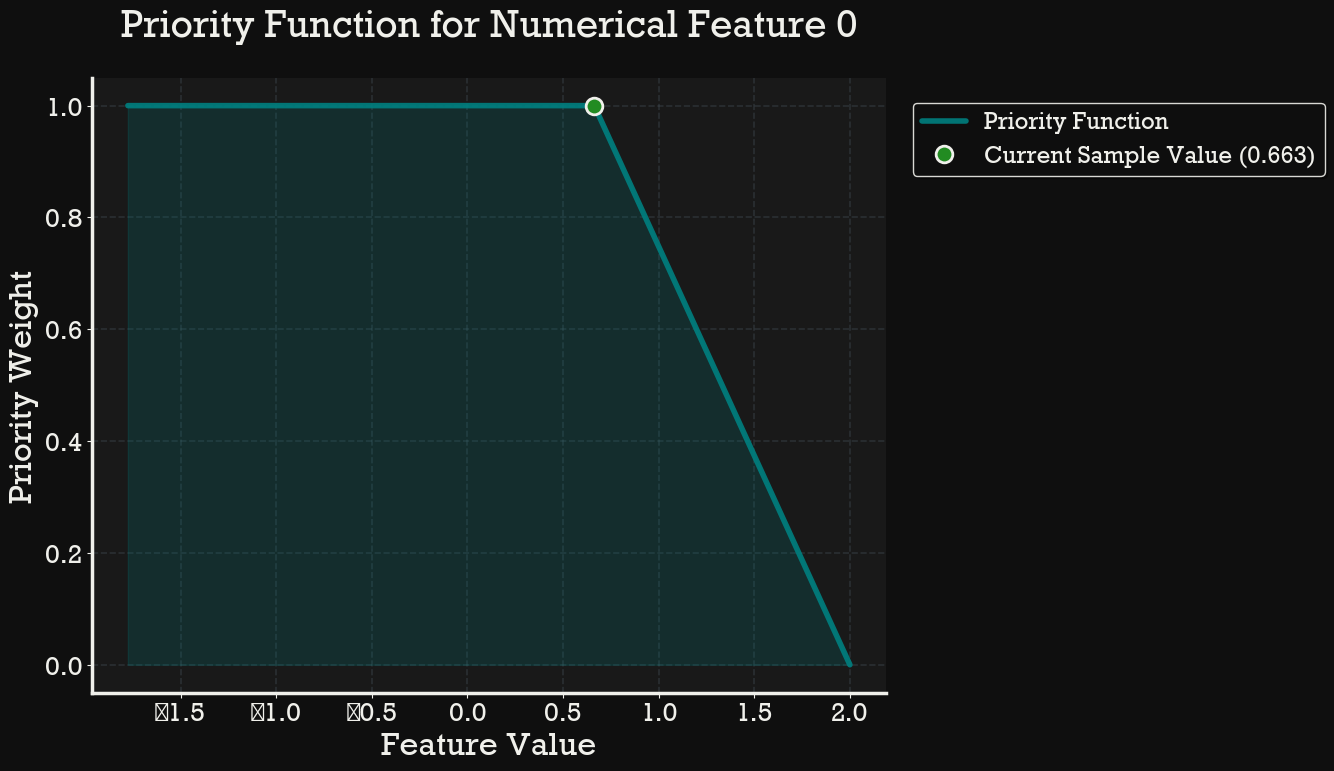

Feature 1 is unactionable with fixed value: 0


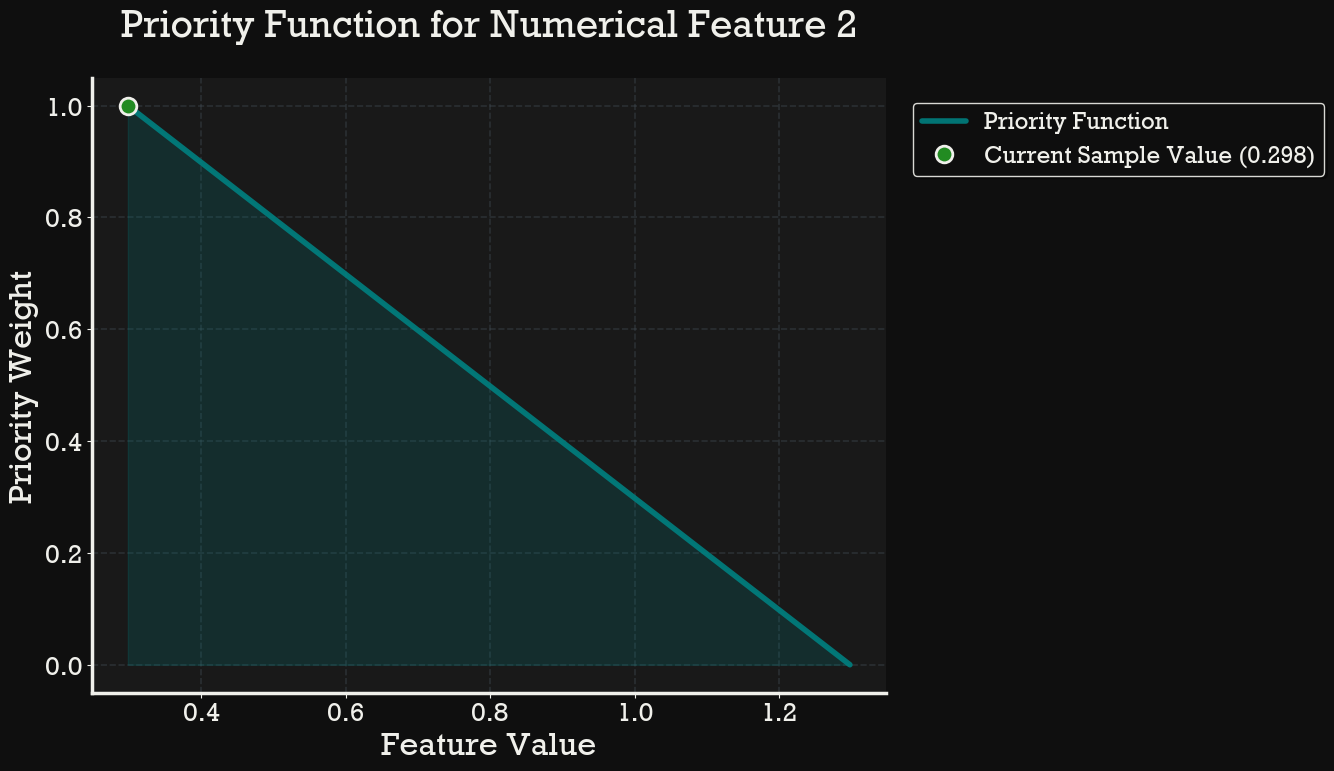

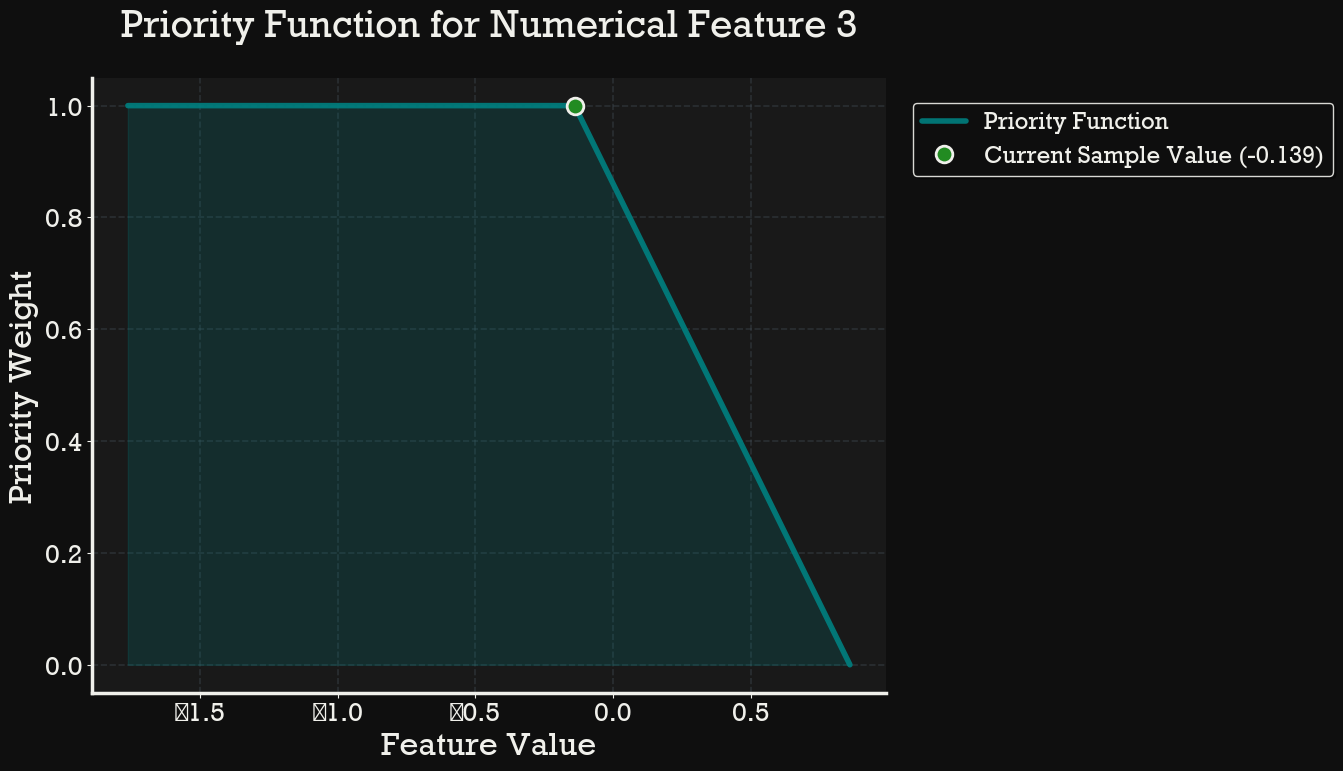

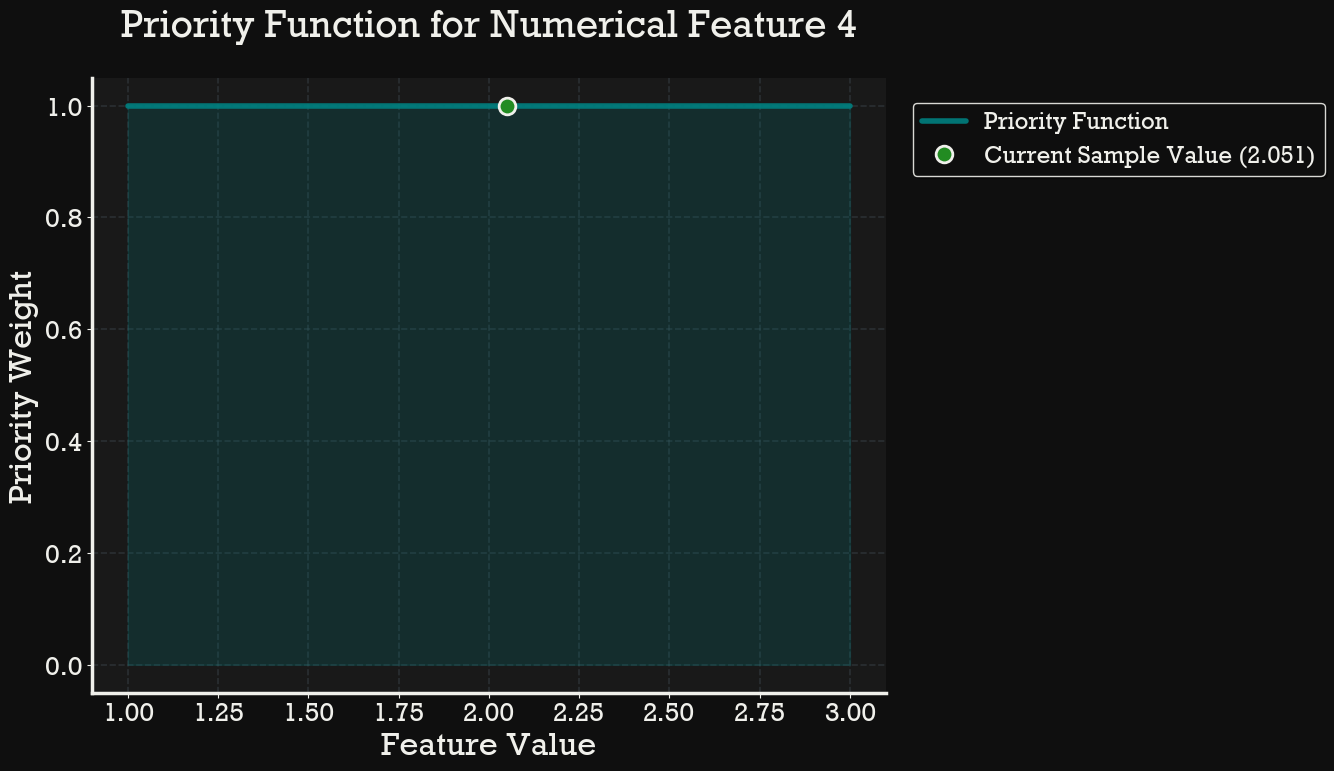

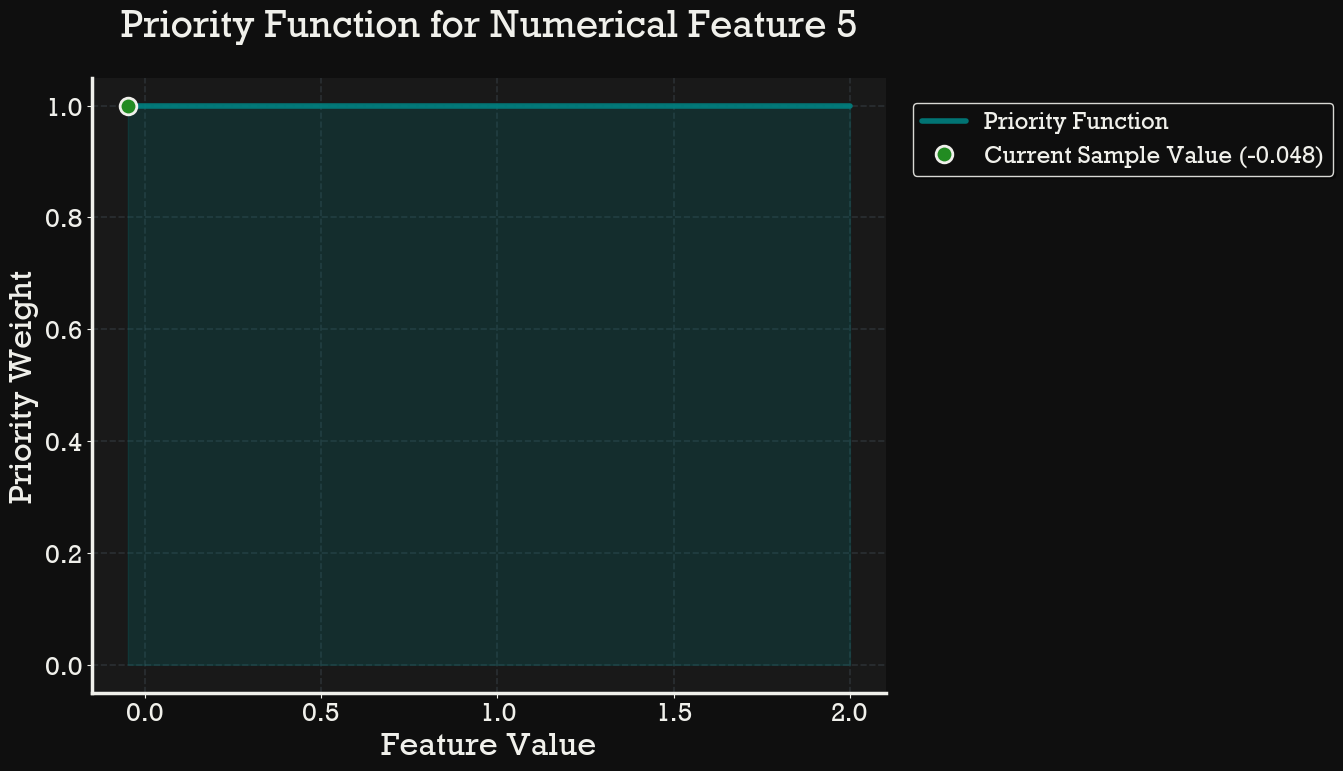

Feature 6 is unactionable with fixed value: 0
Feature 7 is unactionable with fixed value: 0


In [67]:
explainer.display_priorities()

In [ ]:

import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s'
)

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

from explainit.priorities.nonlinear import exponential
from explainit.explainers.minlp_search import MINLSearchExplainer

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [2]:
# Example: Load German Credit dataset
df = pd.read_csv('data/german_credit_data.csv')  # Replace with your dataset path

# Improved preprocessing for your dataset

# Drop 'Unnamed: 0' as it's just an index
df = df.drop(columns=['Unnamed: 0'])

# Handle missing values in categorical columns by filling with 'missing'
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
num_cols = ['Age', 'Credit amount','Duration']

df[cat_cols] = df[cat_cols].fillna('missing')

# Encode target: convert 'Risk' to binary (e.g., 'good' = 1, 'bad' = 0)
df['target'] = (df['Risk'] == 'good').astype(int)
df = df.drop(columns=['Risk'])

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Scale numerical features
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=X.index)
X = pd.concat([X[num_cols], X_cat], axis=1)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']


scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
X = pd.concat([X[num_cols], X_cat], axis=1)
for col in encoder.get_feature_names_out(encoder.feature_names_in_):
    X[col] = X[col].astype('category')
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and check accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.76




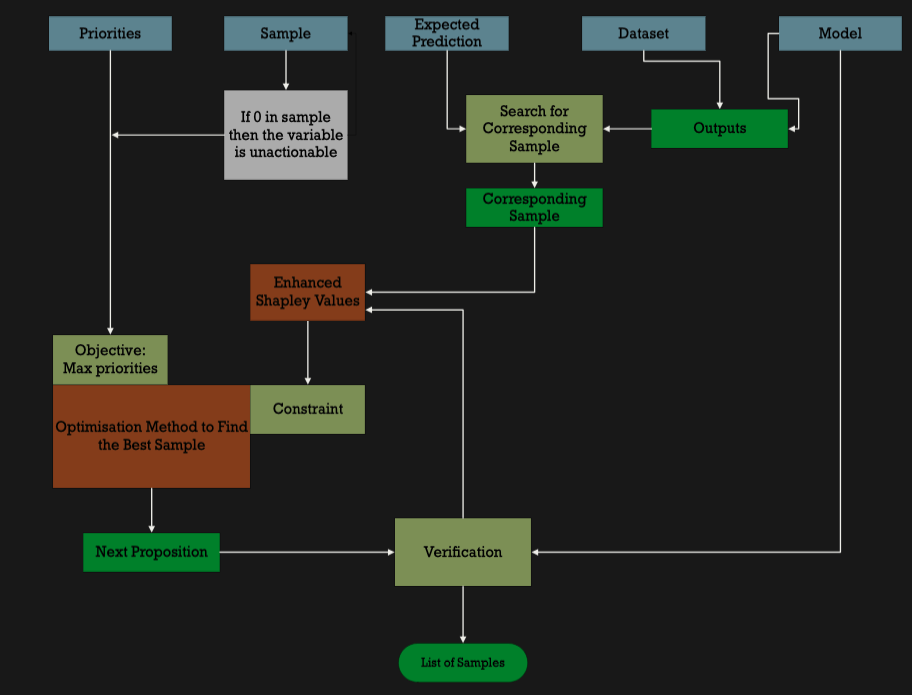

## 1. Select sample for analysis

In [3]:
sample = [                          # Features:
    0.69642857,                     # Age
    0.86359635,                     # Credit amount
    0.73529412,                     # Duration
    0., 1.,                         # Sex
    0., 0., 1., 0.,                 # Job
    0., 0., 1.,                     # Housing
    1., 0., 0., 0., 0.,             # Saving accounts
    0., 0., 1., 0.,                 # Checking account
    1., 0., 0., 0., 0., 0., 0., 0.  # Purpose
    ]

## 2. Select model and requested target
In this scenario, the requested target is probability of classification as class '1'. We want to get probability equal to $60\%$. Note, that we cannot use output of the model (model.predict), which output only $0$ or $1$. We need to use model.predict_proba available in LogisticRegression of SciKit-learn. In this case the output are two values: (probability of class '0', probability of class '1'). We are interested only in the latter, so we select $0.60$ as out requested target, meaning "probability of class '1'".

In [4]:
model_pred = lambda x: model.predict_proba(x)[:,1] # selecting output interesting for me
target = 0.60

## 3. Indicate barriers and priorities. 
By "barriers" we mean min/max values. By "priorities" we mean weight functions that indicate which values of features are preferable to us and which are not.

### Detailed instructions
The priorities need to be written in dictionary of such format:
```python
{
    'numerical':{
        index x: <priority value>,
        index y: <priority value>,
        ...
    }

    'categorical':{
        (index a1, index b1, ..., index n1) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        },
        (index a2, index b2, ..., index n2) : {
            (1, 0, ..., 0) : <priority value>,
            (0, 1, ..., 0) : <priority value>,
            ...
        }
        ...
    }
}
```

- Numerical (continuous) features:
  - unactionable : use int 0 instead of ```<priority value>```, this means that the value from the sample will be used and will not participate in selection based on priority
  - actionable: use ```{'function':<f(x)>,'min': <min value>, 'max': <max value>}```
    - replace ```<f(x)>``` with given function $f : [0, 1]$ 
    - replace ```<min value>``` and ```<max value>``` with respective values (floats or integers)
- Categorical features:
  - for given indices (index a1, index b1, ..., index n1) create dictionary mapping all possible categories to $0$ (don't use) or $1$ (can be used). The algorithm will then be able to use allowed categories and omit forbidden. You can also use other values than $1$ for permitted categories form range $(0, 1]$ to indicate priority. In this case, larger value makes the priority higher.

### Column names
The column names and indices in this example are as follows:
```python
'column': index

'Age': 0
'Credit amount': 1
'Duration': 2

'Sex_female': 3
'Sex_male': 4

'Job_0': 5
'Job_1': 6
'Job_2': 7
'Job_3':8

'Housing_free': 9
'Housing_own': 10
'Housing_rent': 11

'Saving accounts_little': 12
'Saving accounts_missing': 13
'Saving accounts_moderate': 14
'Saving accounts_quite rich': 15
'Saving accounts_rich': 16

'Checking account_little': 17
'Checking account_missing': 18
'Checking account_moderate': 19
'Checking account_rich': 20

'Purpose_business': 21
'Purpose_car': 22
'Purpose_domestic appliances': 23
'Purpose_education': 24
'Purpose_furniture/equipment': 25
'Purpose_radio/TV': 26
'Purpose_repairs': 27
'Purpose_vacation/others': 28
```

In [5]:
min_cred_am = 0.35 # 0.45 #0.65
max_cred_am = X.iloc[1,:].max()
min_duration = 0.30 # 0.40 #0.60
max_duration = X.iloc[2,:].max()

def cred_am_weight(x):
    return exponential(x, x0=0.65, x1=0.86, increasing=True, a = 5)

def duration_weight(x):
    return exponential(x, x0=0.60, x1=0.73, increasing=True, a = 5)

priorities = {
    'numerical':{0: 0, # unactionable
                1: {'function':cred_am_weight,'min':min_cred_am, 'max':max_cred_am},
                2: {'function':duration_weight,'min':min_duration, 'max':max_duration}
},
    'categorical':{
                (3,4): {(1.0, 0.0): 0,
                        (0.0, 1.0): 1},
                (5,6,7,8): {(1.0,0.0,0.0,0.0): 0,
                            (0.0,1.0,0.0,0.0): 0,
                            (0.0,0.0,1.0,0.0): 1,
                            (0.0,0.0,0.0,1.0): 1},
                (9,10,11): {(1.0, 0.0, 0.0): 1,
                            (0.0, 1.0, 0.0): 1,
                            (0.0, 0.0, 1.0): 1},
                (12,13,14,15,16): {(1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 0.0, 1.0, 0.0): 0,
                                    (0.0, 0.0, 0.0, 0.0, 1.0): 0},
                (17,18,19,20): {(1.0, 0.0, 0.0, 0.0): 1,
                                (0.0, 1.0, 0.0, 0.0): 1,
                                (0.0, 0.0, 1.0, 0.0): 1,
                                (0.0, 0.0, 0.0, 1.0): 0},
                (21,22,23,24,25,26,27,28): {(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 1}
    }
}


# 4. I look for the sample that results in a prediction the closest to the specified target

In [6]:
explainer = MINLSearchExplainer(model_pred, priorities, sample, target, dataset=X.values, target_exemplar_epsilon=0.01)
# explainer.find_closest_elem(epsilon=0.01)

2025-11-03 12:37:40,226 - INFO - explainit - Finding the closest element in the dataset based on the specified priorities...


# 5. Calculate Shapley values between original and newly selected sample

In [ ]:
# Calculating Shapley values - how each features moved the prediction from the original sample to the "closest" one

# shap_vals = explainer.calc_shapley(r=explainer.sample)

# 6. Use Shapley values with priorities from point 3 and find the most optimal combination of variables 

In [8]:
counterfactuals = explainer.find_counterfactuals()

2025-11-03 12:38:39,511 - INFO - explainit - linear_solution["success"]: False
2025-11-03 12:38:39,511 - INFO - explainit - solution: None
2025-11-03 12:38:39,513 - INFO - explainit - linear_solution["success"]: True
2025-11-03 12:38:39,513 - INFO - explainit - solution: [0.39948104 0.3       ]
2025-11-03 12:38:39,513 - INFO - explainit - sample: [0.69642857, 0.86359635, 0.73529412, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 12:38:39,513 - INFO - explainit - dummy_x: [0.69642857, np.float64(0.39948104452752864), np.float64(0.3), 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2025-11-03 12:38:39,514 - INFO - explainit - constraint_function: 0.6
2025-11-03 12:38:39,517 - INFO - explainit - linear_solution["success"]: False
2025-11-03 12:38:39,517 - INFO - explainit - solution: None
2025-11-03 12:38:39,519 - IN

In [9]:
counterfactuals

[[np.float64(0.69642857),
  np.float64(0.39948104452752864),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.8711079530441714),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.35),
  np.float64(0.5808767421431051),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 [np.float64(0.69642857),
  np.float64(0.3753359471325555),
  np.float64(0.3),
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
